In [ ]:
import pybaseball as pyb
import seaborn as sns
import matplotlib.pyplot as plt

# Player Identification

Here we are using Nico Hoerner

In [132]:
pyb.playerid_lookup('hoerner', 'nico')

mlb_id = pyb.playerid_lookup('hoerner', 'nico')["key_mlbam"].iloc[0]
mlb_fname = pyb.playerid_lookup('hoerner', 'nico')["name_first"].iloc[0].capitalize()
mlb_lname = pyb.playerid_lookup('hoerner', 'nico')["name_last"].iloc[0].capitalize()

In [133]:
batter_stats = pyb.statcast_batter('2025-03-18', '2025-09-28', mlb_id)

Gathering Player Data


In [134]:
event_groups = {
    "single": "Hit",
    "double": "Hit",
    "triple": "Hit",
    "home_run": "Hit",

    "field_out": "Out",
    "strikeout": "Out",
    "force_out": "Out",
    "grounded_into_double_play": "Out",
    "double_play": "Out",
    "fielders_choice_out": "Out",

    "walk": "Other",
    "field_error": "Other",
    "sac_fly": "Other",
    "hit_by_pitch": "Other",
    "intent_walk": "Other",
    "fielders_choice": "Other",
    "truncated_pa": "Other"
}

In [142]:
spray = batter_stats[["events", "hc_x", "hc_y"]].copy()

spray['events'] = spray['events'].map(event_groups)

spray['hc_x'] = spray['hc_x'] - 125.42

spray['hc_y'] = 198.27 - spray['hc_y']

spray_pal = ['red', 'blue', 'red']

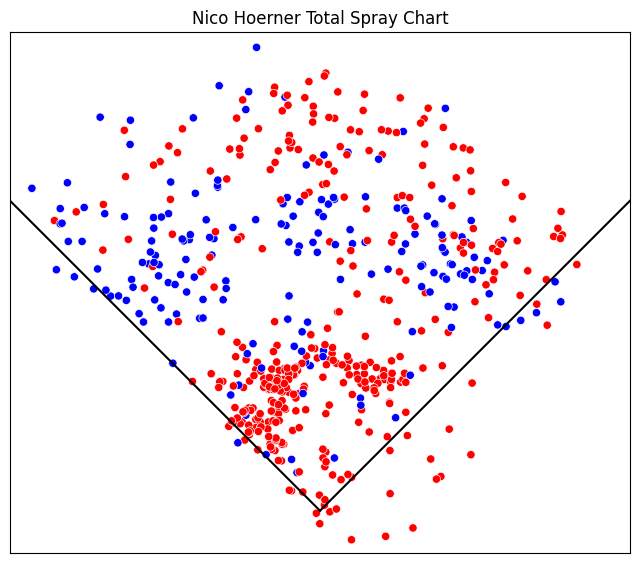

In [145]:
plt.figure(figsize = (8, 8))

sns.scatterplot(
    x=spray['hc_x'],
    y=spray['hc_y'],
    hue = spray['events'],
    legend = False,
    palette = spray_pal
)

plt.title(f'{mlb_fname} {mlb_lname} Total Spray Chart')

plt.xlabel('')
plt.ylabel('')

plt.xlim(-110, 110)
plt.ylim(-15, 170)

plt.xticks([])
plt.yticks([])

plt.plot([0, 110], [0, 110], color = 'black')
plt.plot([-110, 0], [110, 0], color = 'black')

plt.gca().set_aspect('equal', adjustable = 'box')

plt.show()

ValueError: Invalid RGBA argument: 'Out'

Error in callback <function _draw_all_if_interactive at 0x00000266B1A82140> (for post_execute), with arguments args (),kwargs {}:


ValueError: Invalid RGBA argument: 'Out'

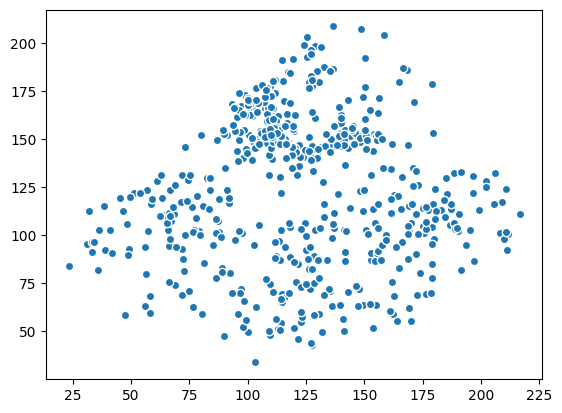

In [30]:
sns.scatterplot(x=hoener_stats['hc_x'],
                y=hoener_stats['hc_y'],
                hue=hoener_stats['events'],
                legend=False,
                palette=event_groups)

<Axes: xlabel='hc_x', ylabel='hc_y'>

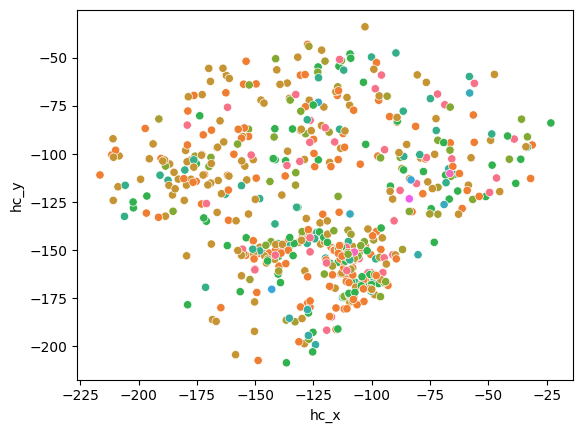

In [6]:
sns.scatterplot(x=hoener_stats['hc_x'],
                y=hoener_stats['hc_y'],
                hue=hoener_stats['pitch_type'],
                legend=False)